In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ANALYTICS_DIR = "sálvame/trials_3000_t1"
FULL_HP = 176

matches = pd.read_csv(f"{ANALYTICS_DIR}/matches.csv")
rounds  = pd.read_csv(f"{ANALYTICS_DIR}/rounds.csv")
actions = pd.read_csv(
    f"{ANALYTICS_DIR}/actions.csv",
    dtype={"matchup": "category", "p1_name": "category", "p2_name": "category",
           "player": "category", "player_name": "category", "action": str,
           "episode": "int32", "round": "int8", "count": "int32"},
)

MATCHUPS = [
    "Curriculum_vs_CPU",
    "Rewards_vs_CPU",
    "Curriculum_vs_Rewards",
    "Rewards_vs_Curriculum",
]

print("Rows loaded:")
print(f"  matches : {len(matches):,}")
print(f"  rounds  : {len(rounds):,}")
print(f"  actions : {len(actions):,}")

Rows loaded:
  matches : 12,000
  rounds  : 29,223
  actions : 7,618,615


---
## 1 — Win Rate Summary

In [2]:
def pct(n, d):
    return 100 * n / d if d else 0.0

rows = []
for mu in MATCHUPS:
    p1_name, p2_name = mu.split("_vs_")
    for level, df, wcol in [
        ("match", matches[matches.matchup == mu], "match_winner"),
        ("round", rounds[rounds.matchup == mu],   "round_winner"),
    ]:
        p1   = (df[wcol] == "p1").sum()
        p2   = (df[wcol] == "p2").sum()
        draw = (df[wcol] == "draw").sum()
        tot  = len(df)
        rows.append({
            "matchup":    mu,
            "level":      level,
            "p1_name":    p1_name,
            "p2_name":    p2_name,
            "p1_wins":    p1,
            "p2_wins":    p2,
            "draws":      draw,
            "total":      tot,
            "p1_win_pct": round(pct(p1, tot), 1),
            "p2_win_pct": round(pct(p2, tot), 1),
            "draw_pct":   round(pct(draw, tot), 1),
        })

summary_df = pd.DataFrame(rows)
summary_df

,matchup,level,p1_name,p2_name,p1_wins,p2_wins,draws,total,p1_win_pct,p2_win_pct,draw_pct
0,Curriculum_vs_CPU,match,Curriculum,CPU,1796,1174,30,3000,59.9,39.1,1.0
1,Curriculum_vs_CPU,round,Curriculum,CPU,4071,3296,51,7418,54.9,44.4,0.7
2,Rewards_vs_CPU,match,Rewards,CPU,1858,1128,14,3000,61.9,37.6,0.5
3,Rewards_vs_CPU,round,Rewards,CPU,4231,3191,22,7444,56.8,42.9,0.3
4,Curriculum_vs_Rewards,match,Curriculum,Rewards,2828,160,12,3000,94.3,5.3,0.4
5,Curriculum_vs_Rewards,round,Curriculum,Rewards,5761,1034,29,6824,84.4,15.2,0.4
6,Rewards_vs_Curriculum,match,Rewards,Curriculum,2272,723,5,3000,75.7,24.1,0.2
7,Rewards_vs_Curriculum,round,Rewards,Curriculum,4849,2671,17,7537,64.3,35.4,0.2


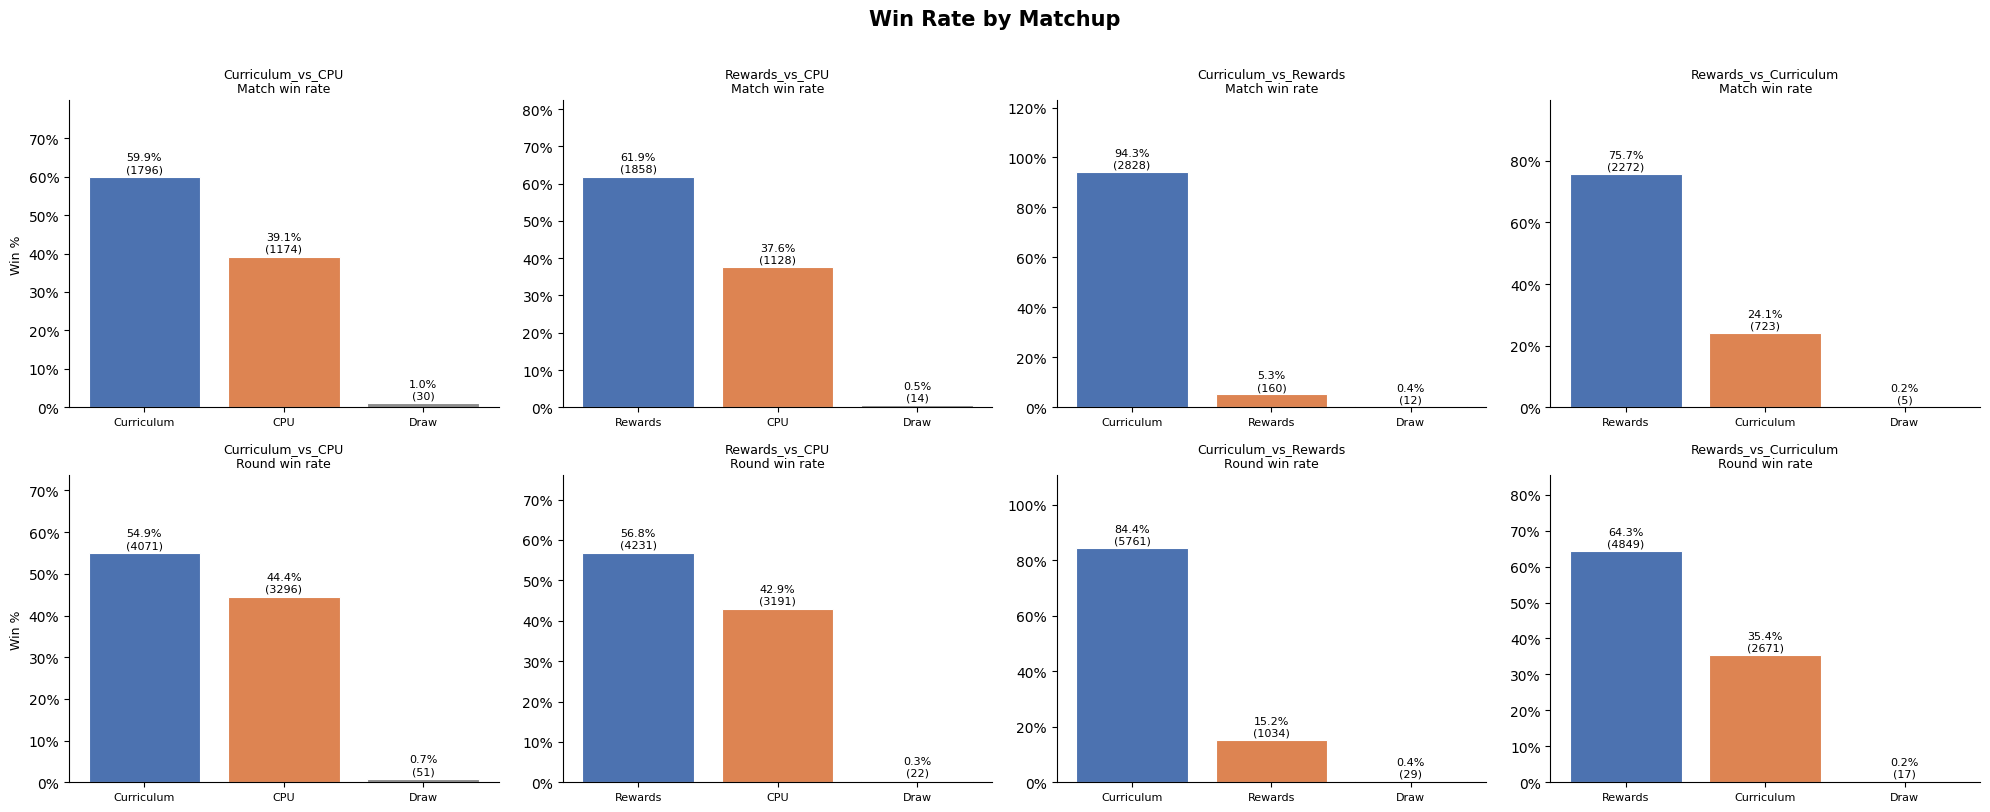

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
fig.suptitle("Win Rate by Matchup", fontsize=15, fontweight="bold", y=1.01)

BAR_COLORS = ["#4C72B0", "#DD8452", "#8c8c8c"]

for col, mu in enumerate(MATCHUPS):
    for row, level in enumerate(["match", "round"]):
        ax   = axes[row][col]
        row_ = summary_df[(summary_df.matchup == mu) & (summary_df.level == level)].iloc[0]

        labels = [row_["p1_name"], row_["p2_name"], "Draw"]
        vals   = [row_["p1_win_pct"], row_["p2_win_pct"], row_["draw_pct"]]
        counts = [row_["p1_wins"],    row_["p2_wins"],    row_["draws"]]

        bars = ax.bar(labels, vals, color=BAR_COLORS, edgecolor="white", linewidth=0.8)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8,
                    f"{bar.get_height():.1f}%\n({cnt})",
                    ha="center", va="bottom", fontsize=8)

        ax.set_ylim(0, max(vals) * 1.25 + 5)
        ax.set_ylabel("Win %" if col == 0 else "", fontsize=9)
        ax.set_title(f"{mu}\n{level.capitalize()} win rate", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.tick_params(axis="x", labelsize=8)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

---
## 2 — Action Distributions

In [4]:
BUTTONS = ['B', 'A', 'MODE', 'START', 'UP', 'DOWN', 'LEFT', 'RIGHT', 'C', 'Y', 'X', 'Z']

SF_COMBOS_BUTTONS = [
    [['DOWN'], ['DOWN', 'RIGHT'], ['RIGHT'], ['X']],  # Hadouken facing right
    [['RIGHT'], ['DOWN'], ['DOWN', 'RIGHT'], ['X']],  # Shoryuken facing right
    [['DOWN'], ['DOWN', 'LEFT'], ['LEFT'], ['A']],    # Tatsumaki facing right
    [['DOWN'], ['DOWN', 'LEFT'], ['LEFT'], ['X']],    # Hadouken facing left
    [['LEFT'], ['DOWN'], ['DOWN', 'LEFT'], ['X']],    # Shoryuken facing left
    [['DOWN'], ['DOWN', 'RIGHT'], ['RIGHT'], ['A']],  # Tatsumaki facing left
]

DIRECTIONS_BUTTONS = [
    [],                              # No direction (neutral)
    ['UP'], ['DOWN'],
    ['LEFT'], ['RIGHT'],
    ['UP', 'LEFT'],
    ['UP', 'RIGHT'],
    ['DOWN', 'LEFT'],  # crouching block
    ['DOWN', 'RIGHT'], # crouching block
]

ATTACKS_BUTTONS = [
    [],           # No attack (neutral)
    ['B'], ['A'], ['C'],  # Light / medium / strong punch (Genesis mapping)
    ['Y'], ['X'], ['Z'],  # Light / medium / strong kick
]

In [5]:
COMBO_NAMES = {
    0: "Hadouken →",
    1: "Shoryuken →",
    2: "Tatsumaki →",
    3: "Hadouken ←",
    4: "Shoryuken ←",
    5: "Tatsumaki ←",
}

_combo_re = re.compile(r"\s*\[combo (\d+)\]$")

def label_action(s):
    m = _combo_re.search(s)
    if m:
        return COMBO_NAMES.get(int(m.group(1)), _combo_re.sub("", s))
    return s

actions["display_action"] = actions["action"].apply(label_action)

def top_actions(matchup, player_name, top_n=25):
    sl  = actions[(actions.matchup == matchup) & (actions.player_name == player_name)]
    agg = sl.groupby("display_action")["count"].sum().sort_values(ascending=False)
    return agg.head(top_n)

def plot_action_dist(ax, matchup, player_name, color, top_n=25):
    data  = top_actions(matchup, player_name, top_n)
    total = data.sum()
    pcts  = 100 * data / total
    bars  = ax.barh(range(len(pcts)), pcts.values, color=color, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(pcts)))
    ax.set_yticklabels(pcts.index, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("% of all steps", fontsize=8)
    ax.set_title(f"{player_name}  ({matchup})", fontsize=9, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.spines[["top", "right"]].set_visible(False)
    for bar, pct_val in zip(bars, pcts.values):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{pct_val:.1f}%", va="center", fontsize=6.5)
    ax.set_xlim(0, pcts.max() * 1.18)
    return ax

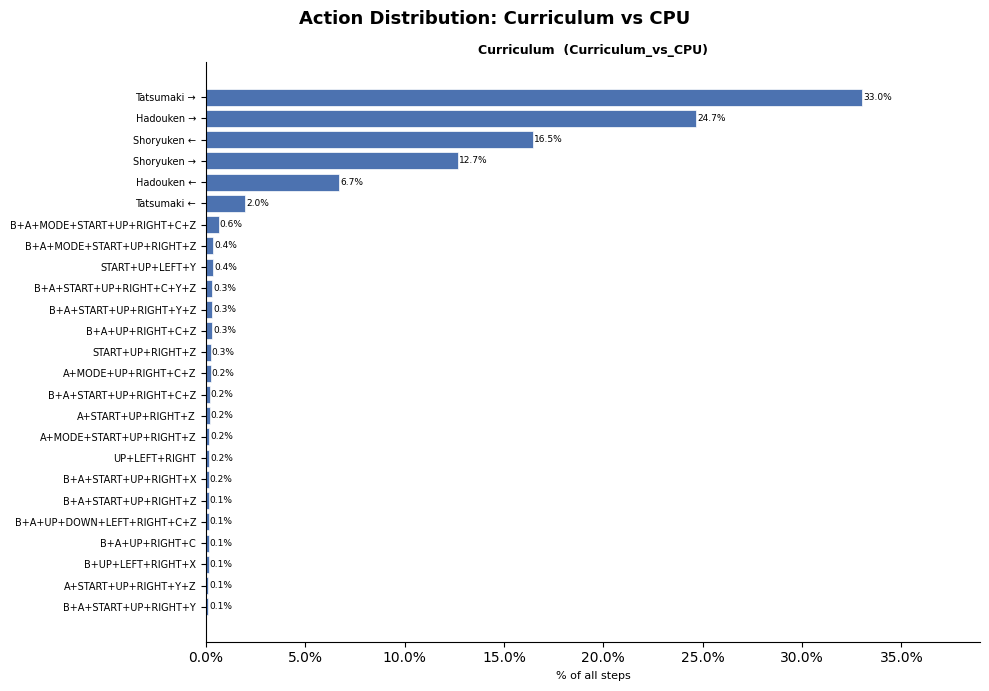

In [11]:
# Chart 1 — Curriculum in Curriculum_vs_CPU
fig, ax = plt.subplots(figsize=(10, 7))
plot_action_dist(ax, "Curriculum_vs_CPU", "Curriculum", "#4C72B0")
fig.suptitle("Action Distribution: Curriculum vs CPU", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

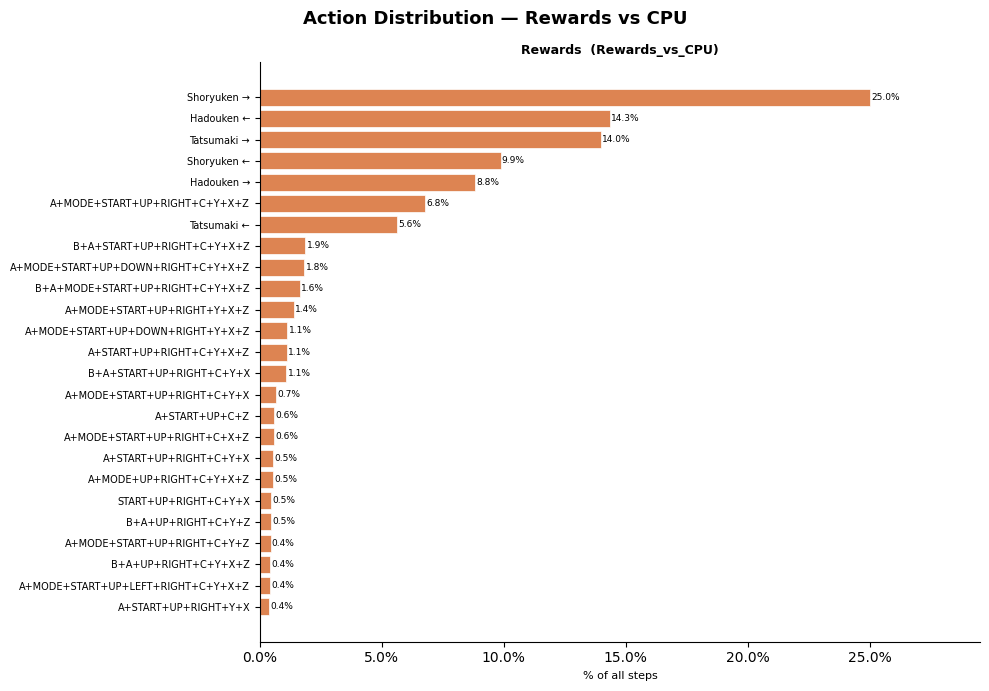

In [7]:
# Chart 2 — Rewards in Rewards_vs_CPU
fig, ax = plt.subplots(figsize=(10, 7))
plot_action_dist(ax, "Rewards_vs_CPU", "Rewards", "#DD8452")
fig.suptitle("Action Distribution: Rewards vs CPU", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

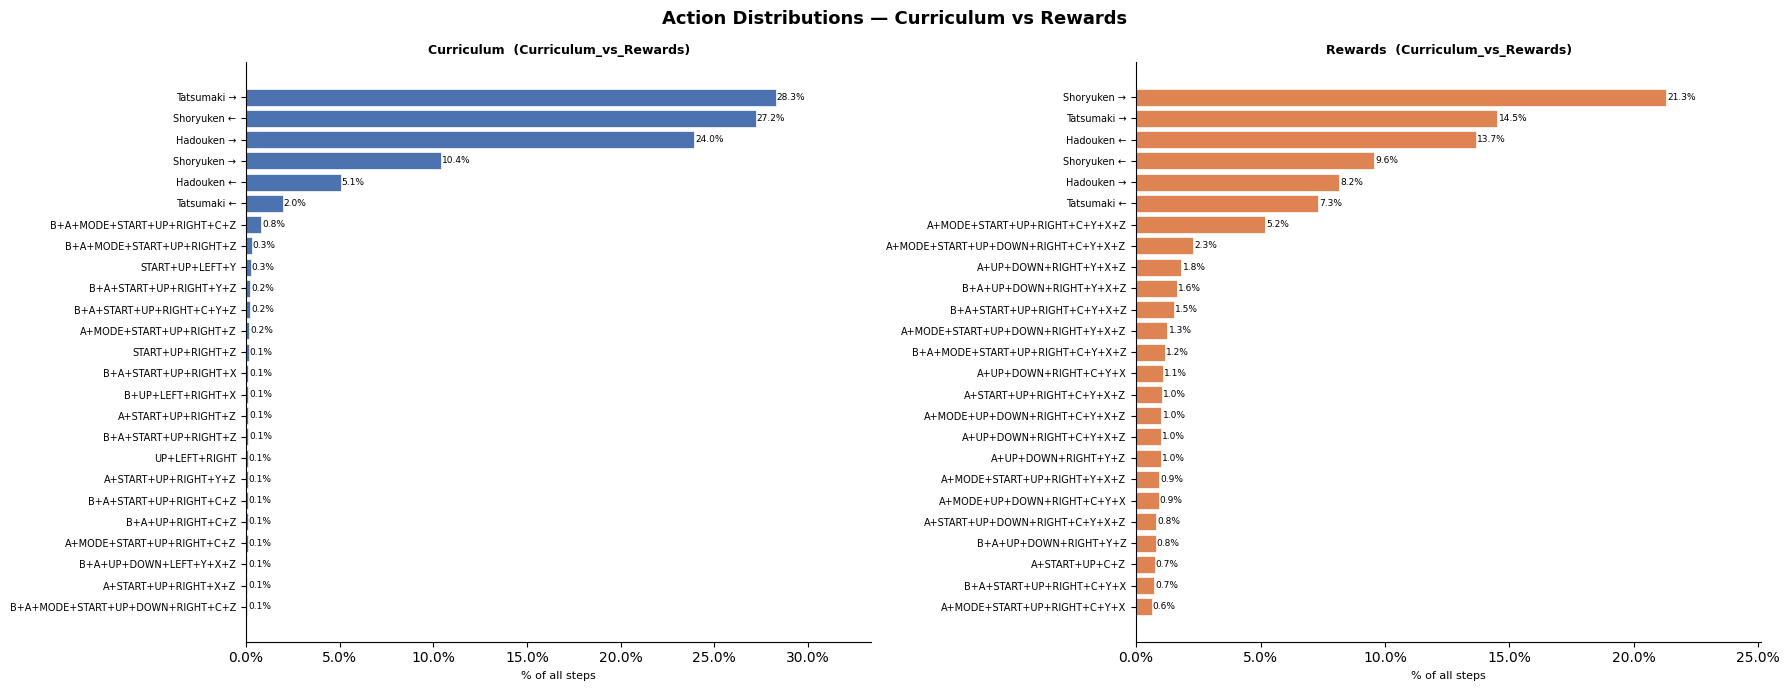

In [8]:
# Charts 3 & 4 — Curriculum and Rewards in Curriculum_vs_Rewards
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plot_action_dist(ax1, "Curriculum_vs_Rewards", "Curriculum", "#4C72B0")
plot_action_dist(ax2, "Curriculum_vs_Rewards", "Rewards",    "#DD8452")
fig.suptitle("Action Distributions: Curriculum vs Rewards", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

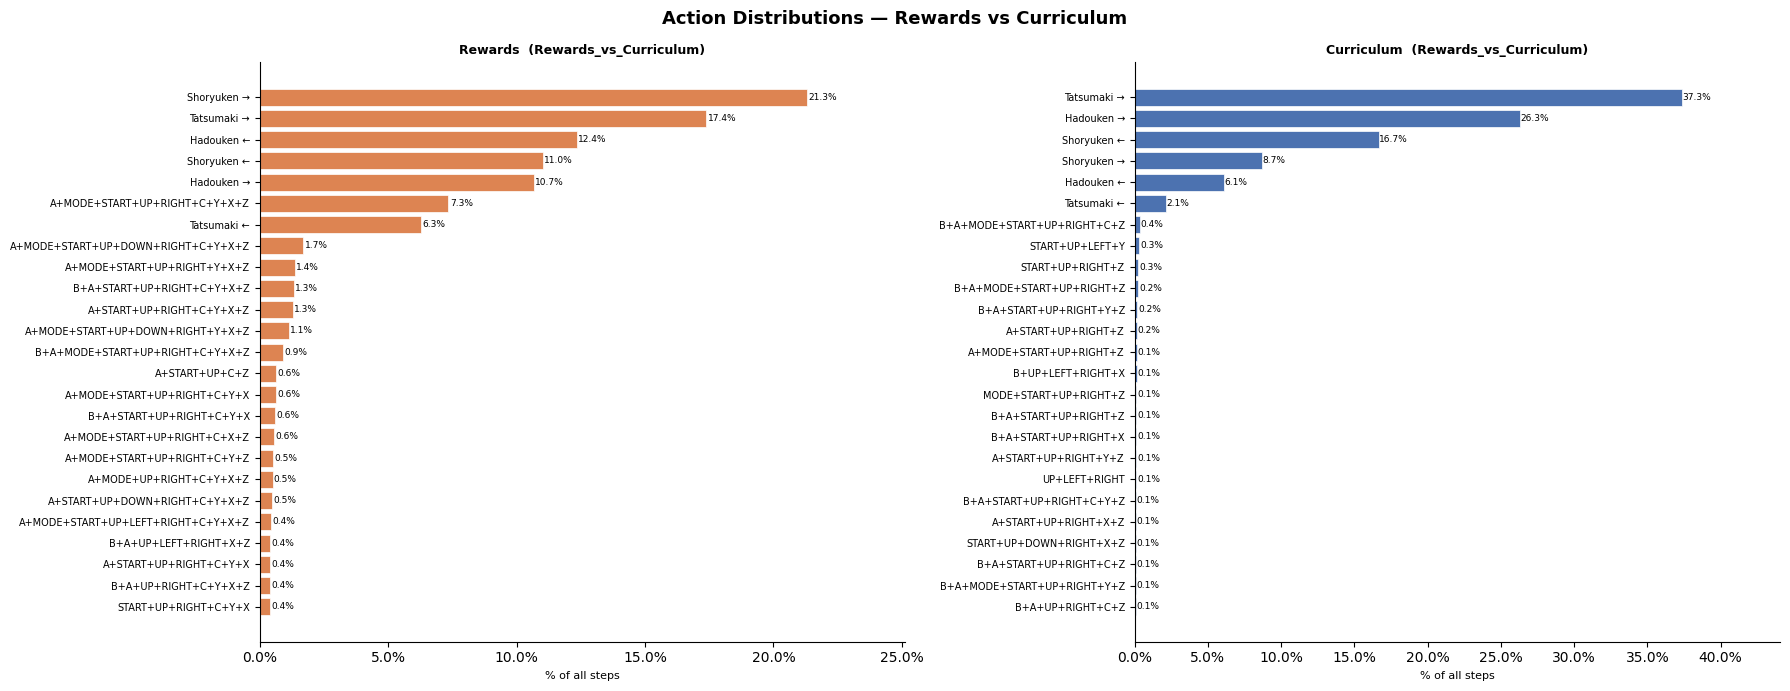

In [9]:
# Charts 5 & 6 — Rewards and Curriculum in Rewards_vs_Curriculum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plot_action_dist(ax1, "Rewards_vs_Curriculum", "Rewards",    "#DD8452")
plot_action_dist(ax2, "Rewards_vs_Curriculum", "Curriculum", "#4C72B0")
fig.suptitle("Action Distributions: Rewards vs Curriculum", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3 — Final Health Difference Histograms

**Value = P1 (left) final HP − P2 (right) final HP.**  
Positive → left player survived with more health.  Negative → right player survived with more health.  
Max range: −176 (left KO'd, right at full HP) to +176 (right KO'd, left at full HP).

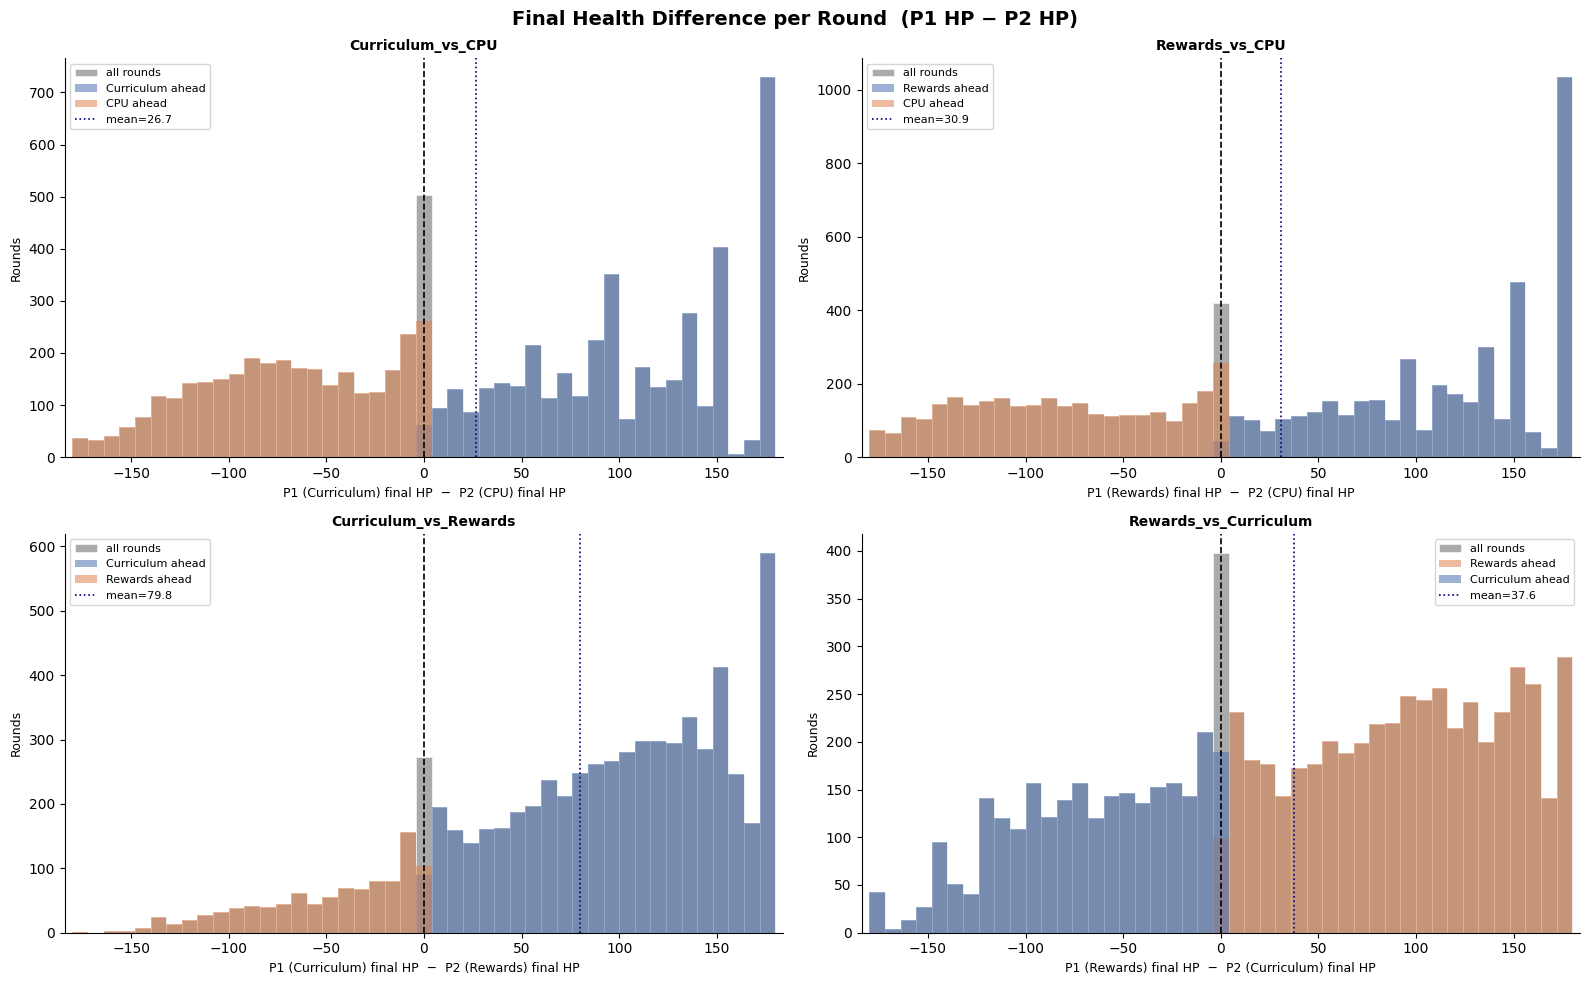

In [10]:
rounds["hp_diff"] = rounds["p1_hp_final"] - rounds["p2_hp_final"]

def plot_hp_diff(ax, matchup, color_left, color_right):
    p1_name, p2_name = matchup.split("_vs_")
    sl = rounds[rounds.matchup == matchup]["hp_diff"]

    bins = np.arange(-FULL_HP - 4, FULL_HP + 8, 8)   # 8-HP bins across full range
    ax.hist(sl, bins=bins, color="#aaaaaa", edgecolor="white", linewidth=0.4, label="all rounds")

    # Shade left-player-wins region green, right-player-wins region red
    pos = sl[sl > 0]
    neg = sl[sl < 0]
    if len(pos):
        ax.hist(pos, bins=bins, color=color_left,  alpha=0.55, edgecolor="none",
                label=f"{p1_name} ahead")
    if len(neg):
        ax.hist(neg, bins=bins, color=color_right, alpha=0.55, edgecolor="none",
                label=f"{p2_name} ahead")

    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.axvline(sl.mean(), color="navy", linewidth=1.2, linestyle=":",
               label=f"mean={sl.mean():.1f}")

    ax.set_xlabel(f"P1 ({p1_name}) final HP  −  P2 ({p2_name}) final HP", fontsize=9)
    ax.set_ylabel("Rounds", fontsize=9)
    ax.set_title(matchup, fontsize=10, fontweight="bold")
    ax.set_xlim(-FULL_HP - 8, FULL_HP + 8)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Final Health Difference per Round  (P1 HP − P2 HP)",
             fontsize=14, fontweight="bold")

configs = [
    ("Curriculum_vs_CPU",        "#4C72B0", "#DD8452"),
    ("Rewards_vs_CPU",           "#4C72B0", "#DD8452"),
    ("Curriculum_vs_Rewards",    "#4C72B0", "#DD8452"),
    ("Rewards_vs_Curriculum",    "#DD8452", "#4C72B0"),
]

for ax, (mu, cl, cr) in zip(axes.flat, configs):
    plot_hp_diff(ax, mu, cl, cr)

plt.tight_layout()
plt.show()